In [2]:
import pandas as pd

# Read the CSV file
file_path = 'data/amine_bonds.csv'
columns = ['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance']
data = pd.read_csv(file_path, delimiter=' ')

# Display the first few rows of the data
print("Number of bonds found:", len(data))
data.tail()


Number of bonds found: 23373547


,timestep,id1,id2,x1,y1,z1,x2,y2,z2,distance
23373542,410000,4814,4812,16.2188,38.5589,39.3568,16.9679,38.2097,38.8522,0.968356
23373543,410000,4814,4878,16.2188,38.5589,39.3568,16.5425,37.7440,39.6830,0.935548
23373544,410000,5109,4812,16.2002,37.9962,38.7960,16.9679,38.2097,38.8522,0.798814
23373545,410000,5109,4878,16.2002,37.9962,38.7960,16.5425,37.7440,39.6830,0.983638
23373546,410000,4812,4878,16.9679,38.2097,38.8522,16.5425,37.7440,39.6830,1.043106


In [9]:
import pandas as pd
import csv

def find_unique_triplets_to_csv(data, output_csv):
    """
    Stream unique triplets directly to CSV (no duplicates, memory-efficient),
    using actual center coordinates.
    """
    with open(output_csv, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["timestep", "id1", "id2", "id3", 
                         "x1", "y1", "z1", "x2", "y2", "z2", "x3", "y3", "z3",
                         "d12", "d13"])

        for timestep, bonds in tqdm(data.groupby("timestep"), total=data['timestep'].nunique(), desc="Finding triplets"):
            adjacency = {}
            center_coords = {}

            # Build adjacency and store center coords
            for _, row in bonds.iterrows():
                i, j = row['id1'], row['id2']

                adjacency.setdefault(i, []).append((j, row['x2'], row['y2'], row['z2'], row['distance']))
                adjacency.setdefault(j, []).append((i, row['x1'], row['y1'], row['z1'], row['distance']))

                # Save center coordinates if not already stored
                if i not in center_coords:
                    center_coords[i] = (row['x1'], row['y1'], row['z1'])
                if j not in center_coords:
                    center_coords[j] = (row['x2'], row['y2'], row['z2'])

            seen_triplets = set()

            for center, partners in adjacency.items():
                if len(partners) < 2:
                    continue

                x1, y1, z1 = center_coords[center]

                for k in range(len(partners) - 1):
                    for l in range(k + 1, len(partners)):
                        id2, x2, y2, z2, d12 = partners[k]
                        id3, x3, y3, z3, d13 = partners[l]

                        # Sorted tuple ensures uniqueness
                        triplet_ids = tuple(sorted([center, id2, id3]))
                        if triplet_ids in seen_triplets:
                            continue
                        seen_triplets.add(triplet_ids)

                        writer.writerow([timestep, *triplet_ids,
                                         x1, y1, z1,
                                         x2, y2, z2,
                                         x3, y3, z3,
                                         d12, d13])


                            
output_csv = 'data/amine_triplets.csv'
find_unique_triplets_to_csv(data, output_csv)


Finding triplets: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40001/40001 [05:52<00:00, 113.50it/s]


In [10]:
triplets = pd.read_csv(output_csv)



In [ ]:
print("Number of triplets found:", len(triplets))
print(triplets.head())

Number of triplets found: 14515874
   timestep    id1    id2    id3       x1       y1        z1       x2  \
0     10000  324.0  625.0  656.0  17.1291  11.5098  0.342398  18.0231   
1     10000  324.0  656.0  658.0  17.1291  11.5098  0.342398  18.0231   
2     10000  625.0  656.0  658.0  17.1291  11.5098  0.342398  17.6551   
3     10000  324.0  625.0  658.0  18.0231  11.2132  0.498590  17.6551   
4     10000  328.0  394.0  660.0  19.6631  14.9009  0.461013  19.5662   

        y2       z2       x3       y3        z3       d12       d13  
0  11.2132  0.49859  17.6551  11.8404  1.074440  0.954779  0.960134  
1  11.2132  0.49859  17.8114  11.9673  0.137391  0.954779  0.846680  
2  11.8404  1.07444  17.8114  11.9673  0.137391  0.960134  0.846680  
3  11.8404  1.07444  17.8114  11.9673  0.137391  0.927581  0.862524  
4  14.1504  1.01963  20.2476  14.3158  0.380719  0.940581  0.830921  


: 

In [3]:
import pandas as pd
import csv
from tqdm import tqdm

def find_multiplets_to_csv(data, output_csv):
    """
    Stream groups of atoms with more than 2 members to CSV.
    Each group has the center and all its bonded neighbors.
    """
    with open(output_csv, mode="w", newline="") as f:
        writer = csv.writer(f)
        # Header: timestep, atom IDs, coordinates
        writer.writerow(["timestep", "center"] + 
                        ["neighbor_id", "neighbor_x", "neighbor_y", "neighbor_z"] * 10)  # max 10 neighbors for example

        for timestep, bonds in tqdm(data.groupby("timestep"), total=data['timestep'].nunique(), desc="Finding groups"):
            adjacency = {}
            center_coords = {}

            # Build adjacency and store center coords
            for _, row in bonds.iterrows():
                i, j = row['id1'], row['id2']

                adjacency.setdefault(i, []).append((j, row['x2'], row['y2'], row['z2']))
                adjacency.setdefault(j, []).append((i, row['x1'], row['y1'], row['z1']))

                if i not in center_coords:
                    center_coords[i] = (row['x1'], row['y1'], row['z1'])
                if j not in center_coords:
                    center_coords[j] = (row['x2'], row['y2'], row['z2'])

            seen_groups = set()

            for center, neighbors in adjacency.items():
                if len(neighbors) < 2:
                    continue

                # Create a sorted tuple of all atom IDs to ensure uniqueness
                group_ids = tuple(sorted([center] + [n[0] for n in neighbors]))
                if group_ids in seen_groups:
                    continue
                seen_groups.add(group_ids)

                row_data = [timestep, center]
                for n_id, nx, ny, nz in neighbors:
                    row_data.extend([n_id, nx, ny, nz])
                writer.writerow(row_data)

output_csv = "data/amine_multiplets.csv"
find_multiplets_to_csv(data, output_csv)


Finding groups: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40001/40001 [04:38<00:00, 143.48it/s]


In [5]:
multiplets = pd.read_csv(output_csv)
print("Number of multiplets found:", len(multiplets))
print(multiplets.head())


Number of multiplets found: 4993131
   timestep  center  neighbor_id  neighbor_x  neighbor_y  neighbor_z  \
0     10000   656.0        324.0     18.0231    11.21320     0.49859   
1     10000   660.0        394.0     19.5662    14.15040     1.01963   
2     10000  3692.0       2898.0     12.0205    18.31800     1.24036   
3     10000   297.0        654.0     11.0365    10.56430     1.54031   
4     10000    66.0       2966.0     20.0428     8.09914     3.56490   

   neighbor_id.1  neighbor_x.1  neighbor_y.1  neighbor_z.1  ...  neighbor_y.7  \
0          625.0       17.6551       11.8404      1.074440  ...           NaN   
1          328.0       20.2476       14.3158      0.380719  ...           NaN   
2         3828.0       11.6445       18.0755      1.895730  ...           NaN   
3          196.0       10.6945       11.0502      2.223920  ...           NaN   
4          627.0       19.0285        8.4737      3.523510  ...           NaN   

   neighbor_z.7  neighbor_id.8  neighbor_x.8

In [14]:
# show distribution of number of neighbours in multiplets (NaN for missing neighbours)
multiplets['num_neighbours'] = (multiplets.count(axis=1) - 3) / 4  # subtract timestep and center columns
print(multiplets['num_neighbours'].value_counts().sort_index())


num_neighbours
2.0    1503782
3.0    3423135
4.0      66147
5.0         67
Name: count, dtype: int64


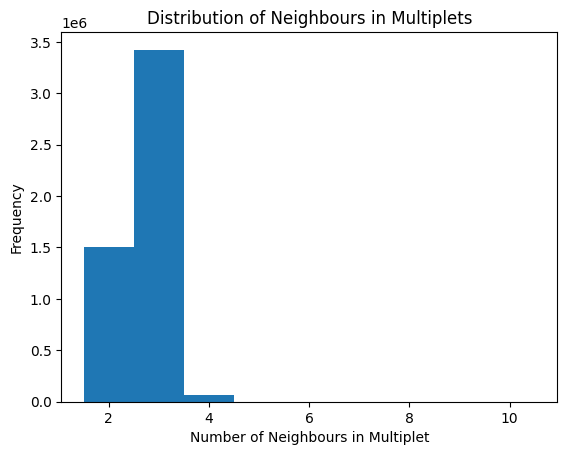

In [19]:
import matplotlib.pyplot as plt

plt.hist(multiplets['num_neighbours'].dropna(), bins=range(2, 12), align='left')
plt.xlabel('Number of Neighbours in Multiplet')
plt.ylabel('Frequency')
plt.title('Distribution of Neighbours in Multiplets')
plt.show()

In [9]:
# import multiprocessing as mp
# import numpy as np

# def process_timestep_range(data, timestep_start, timestep_end, timestep_interval=10):
#     """
#     Process a range of timesteps to find triplets (atoms with more than 2 bonds).
    
#     Args:
#         data: DataFrame containing bond data for all timesteps
#         timestep_start: Start of timestep range (inclusive)
#         timestep_end: End of timestep range (inclusive)
#         timestep_interval: Interval between timesteps to process
    
#     Returns:
#         List of triplet dictionaries found in this timestep range
#     """
#     all_triplets = []
    
#     for timestep in range(timestep_start, timestep_end + 1, timestep_interval):
#         print(f"Processing timestep {timestep}")
#         candidates = data[data['timestep'] == timestep]
        
#         if candidates.empty:
#             continue
            
#         seen_ids = set()
        
#         for _, row in candidates.iterrows():
#             id1, id2 = row['id1'], row['id2']
#             if id1 in seen_ids:
#                 # find other bond with id1
#                 for _, row2 in candidates.iterrows():
#                     if row2['id1'] == id1 and row2['id2'] != id2:
#                         id3 = row2['id2']
#                         pos1 = (row['x1'], row['y1'], row['z1'])
#                         pos2 = (row['x2'], row['y2'], row['z2'])
#                         pos3 = (row2['x2'], row2['y2'], row2['z2'])
#                         dist1 = row['distance']
#                         dist2 = row2['distance']
#                         all_triplets.append({
#                             'timestep': timestep,
#                             'ids': (id1, id2, id3),
#                             'positions': (pos1, pos2, pos3),
#                             'distances': (dist1, dist2)
#                         })
#             elif id2 in seen_ids:
#                 # find other bond with id2
#                 for _, row2 in candidates.iterrows():
#                     if row2['id1'] == id2 and row2['id2'] != id1:
#                         id3 = row2['id2']
#                         pos1 = (row['x1'], row['y1'], row['z1'])
#                         pos2 = (row['x2'], row['y2'], row['z2'])
#                         pos3 = (row2['x2'], row2['y2'], row2['z2'])
#                         dist1 = row['distance']
#                         dist2 = row2['distance']
#                         all_triplets.append({
#                             'timestep': timestep,
#                             'ids': (id1, id2, id3),
#                             'positions': (pos1, pos2, pos3),
#                             'distances': (dist1, dist2)
#                         })
#             seen_ids.add(id1)
#             seen_ids.add(id2)
    
#     return all_triplets

# def find_triplets_parallel(data, timestep_interval=10, num_processes=None, chunk_size=None):
#     """
#     Find triplets in parallel by splitting timestep ranges across processes.
    
#     Args:
#         data: DataFrame containing bond data
#         timestep_interval: Interval between timesteps to process
#         num_processes: Number of processes to use (None for auto-detection)
#         chunk_size: Number of timesteps per chunk (None for auto-calculation)
    
#     Returns:
#         DataFrame containing all found triplets
#     """
#     if num_processes is None:
#         num_processes = mp.cpu_count()
    
#     # Get the full timestep range
#     min_timestep = data['timestep'].min()
#     max_timestep = data['timestep'].max()
#     total_timesteps = len(range(min_timestep, max_timestep + 1, timestep_interval))
    
#     # Calculate chunk size if not provided
#     if chunk_size is None:
#         chunk_size = max(1, total_timesteps // num_processes)
    
#     print(f"Using {num_processes} processes for parallel processing")
#     print(f"Total timesteps to process: {total_timesteps}")
#     print(f"Chunk size: {chunk_size} timesteps per process")
    
#     # Create timestep ranges for each process
#     timestep_ranges = []
#     current_start = min_timestep
    
#     while current_start <= max_timestep:
#         # Calculate the end of this chunk
#         steps_in_chunk = min(chunk_size, (max_timestep - current_start) // timestep_interval + 1)
#         current_end = current_start + (steps_in_chunk - 1) * timestep_interval
#         current_end = min(current_end, max_timestep)
        
#         timestep_ranges.append((current_start, current_end))
#         current_start = current_end + timestep_interval
    
#     print(f"Created {len(timestep_ranges)} chunks:")
#     for i, (start, end) in enumerate(timestep_ranges):
#         print(f"  Chunk {i+1}: timesteps {start} to {end}")
    
#     # Process ranges in parallel
#     with mp.Pool(processes=num_processes) as pool:
#         # Create argument tuples for starmap: (data, start, end, timestep_interval)
#         args_list = [(data, start, end, timestep_interval) for start, end in timestep_ranges]
        
#         results = pool.starmap(process_timestep_range, args_list)
    
#     # Flatten results
#     all_triplets = []
#     for chunk_triplets in results:
#         all_triplets.extend(chunk_triplets)
    
#     print(f"Found {len(all_triplets)} total triplets")
#     return pd.DataFrame(all_triplets)

# # Run the parallel version with chunked timestep ranges
# print("Starting parallel triplet detection with chunked timestep ranges...")
# triplets = find_triplets_parallel(data, timestep_interval=10, num_processes=1)
# print("Parallel processing complete!")
# print(f"Shape of triplets DataFrame: {triplets.shape}")
# if not triplets.empty:
#     print("First few triplets:")
#     print(triplets.head())

# crashes due to memory issues, not used anymore

# Varying energy (A)

Varying the factor in front of the Gaussian, varies depth of the potential well. Also varies the shape of the potential function slightly, which is reflected in the bond lengths below.

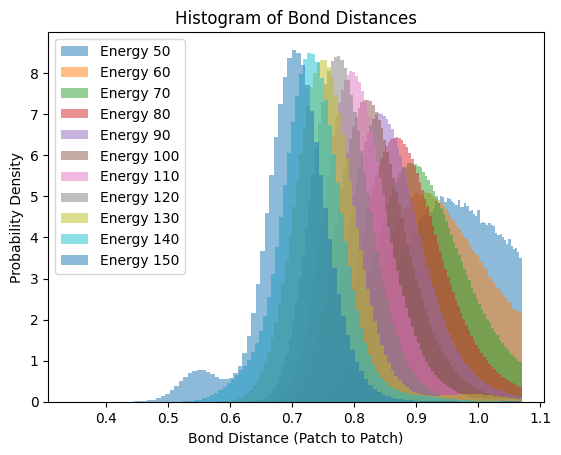

In [11]:
# histogram of bond distances

energies = [50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


import matplotlib.pyplot as plt
import pandas as pd

for energy in energies:
    file = f'data/amine_bonds_{energy}.0.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    plt.hist(data[data['timestep']>5000]['distance'], bins=100, density=True, label=f'Energy {energy}', alpha=0.5)

plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances by Energy (Length=0.45)')
plt.legend()
plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances')
plt.show()


As expected, the deeper the potential well the closer the bonds -- increasing the potential also moves the well closer to the patch. This does serve to manipulate the bond distance between the two 

Let's also see the difference of where multiple bonds are in bond length, triple is expected to be higher as there is more steric hindrance for the closer bond lengths.

This is a plot of what happens when we vary the length between patch to bead, which will change the potential. Note that moving the bead further will bring the potential minimum closer, as there is less repulsion experienced.

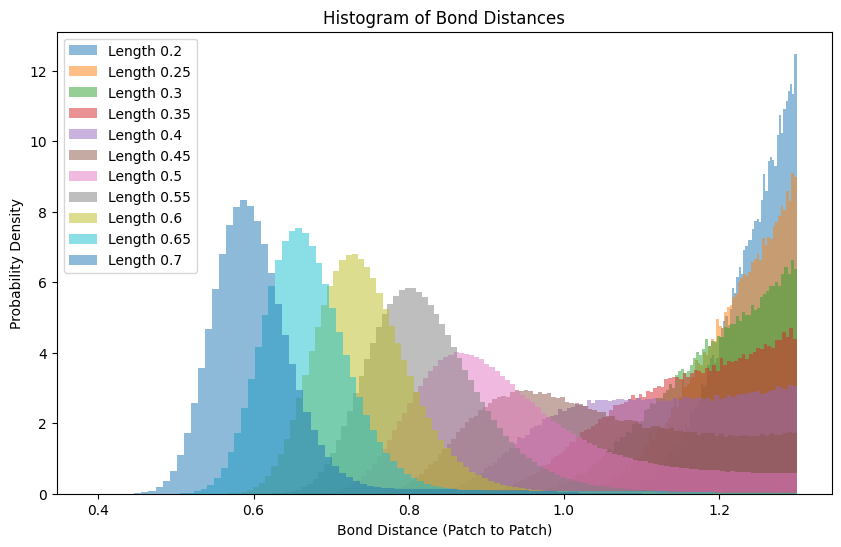

In [10]:
# histogram of bond distances

lengths = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
# lengths = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
# lengths = [0.2, 0.25, 0.3, 0.35, 0.4]



import matplotlib.pyplot as plt
import pandas as pd

figure = plt.figure(figsize=(10, 6))
for length in lengths:
    file = f'data/amine_bonds_{length}.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    plt.hist(data[data['timestep']>5000]['distance'], bins=100, density=True, label=f'Length {length}', alpha=0.5)

plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances by Length (Energy A=50)')
plt.legend()
plt.xlabel('Bond Distance (Patch to Patch)')
plt.ylabel('Probability Density')
plt.title('Histogram of Bond Distances')
plt.show()

Similar to increasing the Gaussian strength, moving the Gaussian further from the repulsive WCA creates a more peaked distribution closer to the patches. At about 0.5 and greater in patch-bead bond length, the bond is no longer behaving as expected and starts having a lot of bonded patches at an equal or greater distance to the backbone distance. The repulsion at this distance does nothing, so this is no longer a working regime.

The number of bonds may change over time, which would imply that the system has not reached bond saturation/equilibrium. This would affect the bond distribution/behaviour. The system should be at equilibrium for us to judge it.

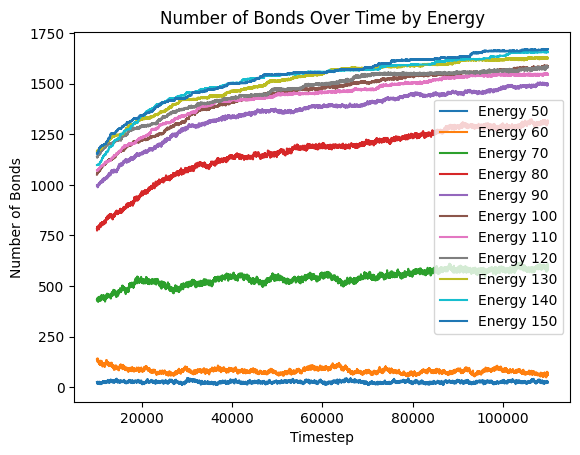

In [12]:
# plot number of bonds over time for each energy
for energy in energies:
    file = f'data/amine_bonds_{energy}.0.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    bond_counts = data['timestep'].value_counts().sort_index()
    plt.plot(bond_counts.index, bond_counts.values, label=f'Energy {energy}')
plt.xlabel('Timestep')
plt.ylabel('Number of Bonds')
plt.title('Number of Bonds Over Time by Energy')
plt.legend()
plt.show()

It looks like they are for the most part at equilirium. Some of the higher energy do seem to still be equilibriating at the beginning but seem to  taper off by the 1/4 of the timesteps. 

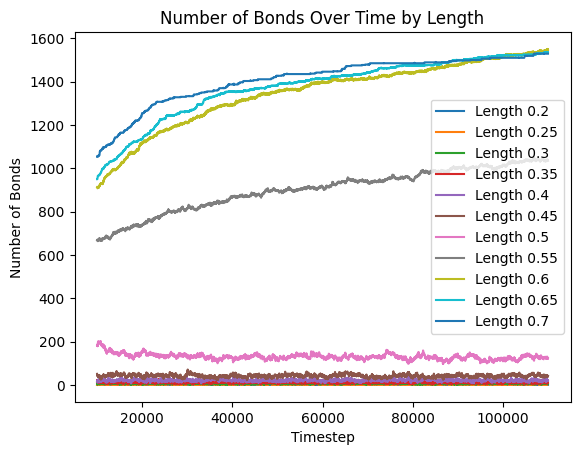

In [15]:
# plot number of bonds over time for each length
for length in lengths:
    file = f'data/amine_bonds_length_{length}.csv'
    data = pd.read_csv(file, skiprows=1, delimiter=' ', names=['timestep', 'id1', 'id2', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2', 'distance'])
    bond_counts = data['timestep'].value_counts().sort_index()
    plt.plot(bond_counts.index, bond_counts.values, label=f'Length {length}')
plt.xlabel('Timestep')
plt.ylabel('Number of Bonds')
plt.title('Number of Bonds Over Time by Length')
plt.legend()
plt.show()

Similarly, changing the length shows the same. We can proceed with examining multiple bonds.

Energy 50 - Average number of neighbours in multiplets: 2.018077377935462
Energy 50 - Distribution of neighbours in multiplets:
num_neighbours
2.0    5812
3.0     107
Name: count, dtype: int64
Energy 60 - Average number of neighbours in multiplets: 2.1765031680623865
Energy 60 - Distribution of neighbours in multiplets:
num_neighbours
2.0    74345
3.0    15928
4.0        3
Name: count, dtype: int64
Energy 70 - Average number of neighbours in multiplets: 2.522731981307981
Energy 70 - Distribution of neighbours in multiplets:
num_neighbours
2.0    609282
3.0    642488
4.0      8013
5.0         6
Name: count, dtype: int64
Energy 80 - Average number of neighbours in multiplets: 2.729505445709521
Energy 80 - Distribution of neighbours in multiplets:
num_neighbours
2.0     819317
3.0    1548934
4.0     140316
5.0        197
Name: count, dtype: int64
Energy 90 - Average number of neighbours in multiplets: 2.6807812654171816
Energy 90 - Distribution of neighbours in multiplets:
num_neighbours


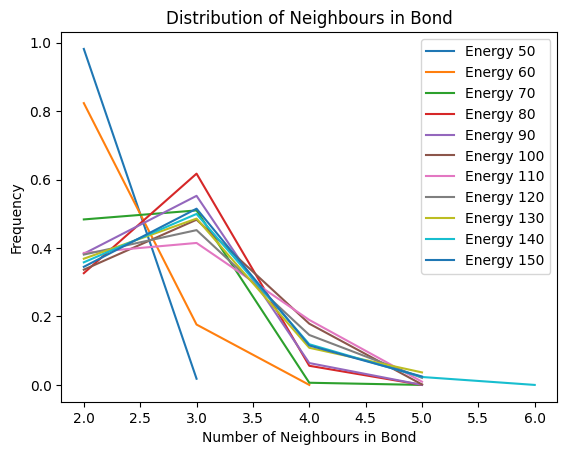

In [22]:
import matplotlib.pyplot as plt

for energy in energies:
    file = f'data/amine_multiplets_{energy}.0.csv'
    data = pd.read_csv(file)
    data['num_neighbours'] = (data.count(axis=1) - 2) / 4  # subtract timestep and center columns
    neighbour_counts = data['num_neighbours'].value_counts().sort_index()
    norm_counts = neighbour_counts / neighbour_counts.sum()
    # plt.hist(data['num_neighbours'].dropna(), bins=range(2, 12), alpha=0.5, label=f'Energy {energy}', align='left')
    plt.plot(range(2, len(norm_counts) + 2), norm_counts, label=f'Energy {energy}')
    print(f"Energy {energy} - Average number of neighbours in multiplets:", data['num_neighbours'].mean())
    print(f"Energy {energy} - Distribution of neighbours in multiplets:")
    print(data['num_neighbours'].value_counts().sort_index())
plt.xlabel('Number of Neighbours in Bond')
plt.ylabel('Frequency')
plt.title('Distribution of Neighbours in Bond')
plt.legend()
plt.show()

# # show distribution of number of neighbours in multiplets (NaN for missing neighbours)
# multiplets['num_neighbours'] = (multiplets.count(axis=1) - 3) / 4  # subtract timestep and center columns
# print(multiplets['num_neighbours'].value_counts().sort_index())


# plt.hist(multiplets['num_neighbours'].dropna(), bins=range(2, 12), align='left')
# plt.xlabel('Number of Neighbours in Multiplet')
# plt.ylabel('Frequency')
# plt.title('Distribution of Neighbours in Multiplets')
# plt.show()


Length 0.2 - Average number of neighbours in multiplets: 2.0
Length 0.2 - Distribution of neighbours in multiplets:
num_neighbours
2.0    103
Name: count, dtype: int64
Length 0.25 - Average number of neighbours in multiplets: 2.0
Length 0.25 - Distribution of neighbours in multiplets:
num_neighbours
2.0    219
Name: count, dtype: int64
Length 0.3 - Average number of neighbours in multiplets: 2.0
Length 0.3 - Distribution of neighbours in multiplets:
num_neighbours
2.0    583
Name: count, dtype: int64
Length 0.35 - Average number of neighbours in multiplets: 2.0025906735751295
Length 0.35 - Distribution of neighbours in multiplets:
num_neighbours
2.0    1155
3.0       3
Name: count, dtype: int64
Length 0.4 - Average number of neighbours in multiplets: 2.009806386723661
Length 0.4 - Distribution of neighbours in multiplets:
num_neighbours
2.0    3938
3.0      39
Name: count, dtype: int64
Length 0.45 - Average number of neighbours in multiplets: 2.017026988837078
Length 0.45 - Distributio

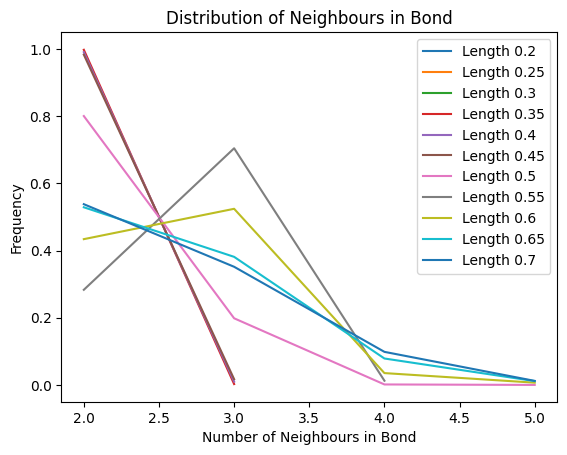

In [19]:
import matplotlib.pyplot as plt

avg_neighbours = []

for length in lengths:
    file = f'data/amine_multiplets_length_{length}.csv'
    data = pd.read_csv(file)
    data['num_neighbours'] = (data.count(axis=1) - 2) / 4  # subtract timestep and center columns
    neighbour_counts = data['num_neighbours'].value_counts().sort_index()
    norm_counts = neighbour_counts / neighbour_counts.sum()
    plt.plot(range(2, len(norm_counts) + 2), norm_counts, label=f'Length {length}')
    avg_neighbours.append(data['num_neighbours'].mean())
    print(f"Length {length} - Average number of neighbours in multiplets:", data['num_neighbours'].mean())
    print(f"Length {length} - Distribution of neighbours in multiplets:")
    print(data['num_neighbours'].value_counts().sort_index())
plt.xlabel('Number of Neighbours in Bond')
plt.ylabel('Frequency')
plt.title('Distribution of Neighbours in Bond')
plt.legend()
plt.show()



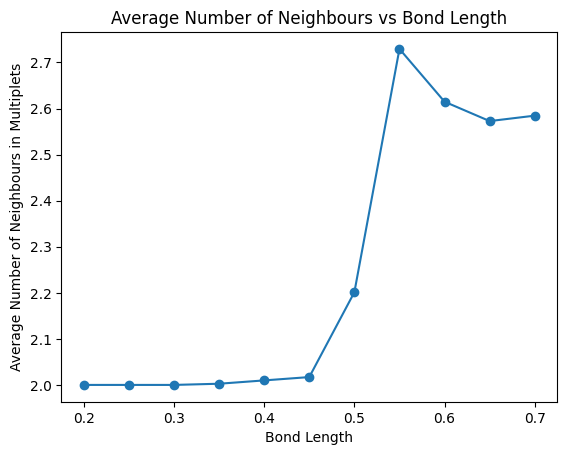

In [20]:
# graph average number of bonds

import matplotlib.pyplot as plt

plt.plot(lengths, avg_neighbours, marker='o')
plt.xlabel('Bond Length')
plt.ylabel('Average Number of Neighbours in Multiplets')
plt.title('Average Number of Neighbours vs Bond Length')
plt.show()

Length 0.2 - Average number of bonds over time: 3.7749512770540568
Length 0.25 - Average number of bonds over time: 5.763316582914573
Length 0.3 - Average number of bonds over time: 8.887511248875112
Length 0.35 - Average number of bonds over time: 13.718228177182281
Length 0.4 - Average number of bonds over time: 22.52884711528847
Length 0.45 - Average number of bonds over time: 43.000099990001
Length 0.5 - Average number of bonds over time: 131.5174482551745
Length 0.55 - Average number of bonds over time: 901.6016398360164
Length 0.6 - Average number of bonds over time: 1347.7107289271073
Length 0.65 - Average number of bonds over time: 1377.2948705129486
Length 0.7 - Average number of bonds over time: 1411.4009599040096


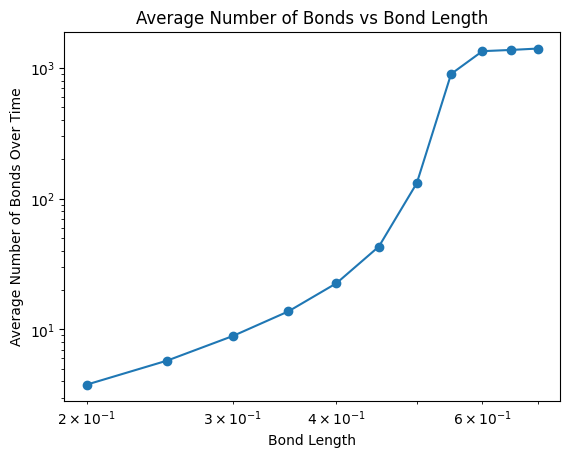

In [26]:
# Bond length vs average number of bonds per timestep

avg_bonds = []

for length in lengths:
    file = f'data/amine_bonds_length_{length}.csv'
    data = pd.read_csv(file, delimiter=' ')
    average_bonds = data['timestep'].value_counts().mean()
    print(f"Length {length} - Average number of bonds over time:", average_bonds)
    avg_bonds.append(average_bonds)

# log axis for better visualization
import matplotlib.pyplot as plt
plt.plot(lengths, avg_bonds, marker='o')
plt.xlabel('Bond Length')
plt.ylabel('Average Number of Bonds Over Time')
plt.title('Average Number of Bonds vs Bond Length')
plt.xscale('log')
plt.yscale('log')
plt.show()
    

Energy 49.0 - Average number of neighbours in multiplets: 2.0
Energy 49.0 - Distribution of neighbours in multiplets:
num_neighbours
2.0    94
Name: count, dtype: int64
Energy 99.0 - Average number of neighbours in multiplets: 2.0
Energy 99.0 - Distribution of neighbours in multiplets:
num_neighbours
2.0    681
Name: count, dtype: int64
Energy 149.0 - Average number of neighbours in multiplets: 2.0069879167273257
Energy 149.0 - Distribution of neighbours in multiplets:
num_neighbours
2.0    6821
3.0      48
Name: count, dtype: int64
Energy 200.0 - Average number of neighbours in multiplets: 2.4243242017416544
Energy 200.0 - Distribution of neighbours in multiplets:
num_neighbours
2.0    266655
3.0    161642
4.0     12530
5.0       124
6.0         9
Name: count, dtype: int64
Energy 300.0 - Average number of neighbours in multiplets: 3.207100351601828
Energy 300.0 - Distribution of neighbours in multiplets:
num_neighbours
2.0    1024728
3.0    2123349
4.0    1792250
5.0     124643
6.0   

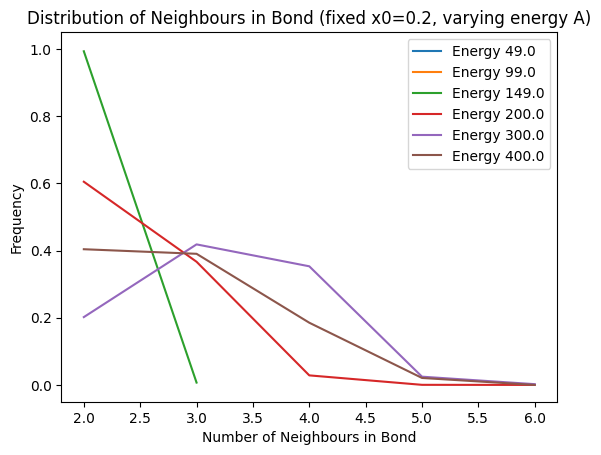

In [29]:
import matplotlib.pyplot as plt

avg_neighbours = []
energies = [49.0, 99.0, 149.0, 200.0, 300.0, 400.0]

for energy in energies:
    file = f'data/amine_multiplets_{energy}.csv'
    data = pd.read_csv(file)
    data['num_neighbours'] = (data.count(axis=1) - 2) / 4  # subtract timestep and center columns
    neighbour_counts = data['num_neighbours'].value_counts().sort_index()
    norm_counts = neighbour_counts / neighbour_counts.sum()
    plt.plot(range(2, len(norm_counts) + 2), norm_counts, label=f'Energy {energy}')
    avg_neighbours.append(data['num_neighbours'].mean())
    print(f"Energy {energy} - Average number of neighbours in multiplets:", data['num_neighbours'].mean())
    print(f"Energy {energy} - Distribution of neighbours in multiplets:")
    print(data['num_neighbours'].value_counts().sort_index())
plt.xlabel('Number of Neighbours in Bond')
plt.ylabel('Frequency')
plt.title('Distribution of Neighbours in Bond (fixed x0=0.2, varying energy A)')
plt.legend()
plt.show()



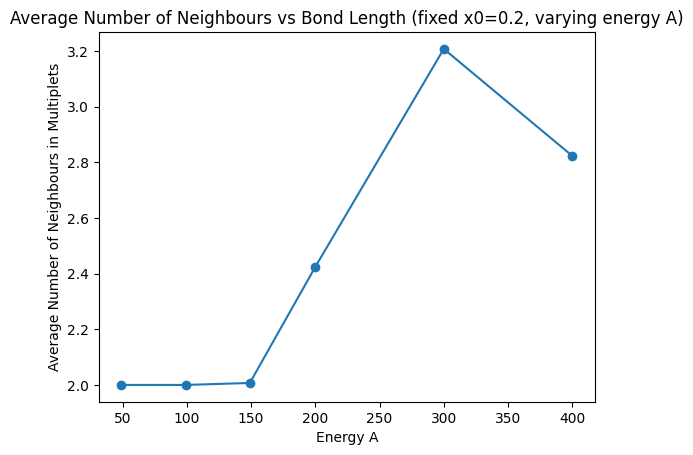

In [ ]:
# graph average number of bonds

import matplotlib.pyplot as plt

plt.plot(energies, avg_neighbours, marker='o')
plt.xlabel('Energy A')
plt.ylabel('Average Number of Neighbours in Multiplets')
plt.title('Average Number of Neighbours vs Energy A (fixed x0=0.2, varying energy A)')
plt.show()

Average bond lifetime: 7.510460592540197
[ 61120 193010  57070  11600  13110   8470   4310   3770   3150   2210
   1670   1510    670    790    930    720    480    510    420    260
    230    250    150    170     70    190    110     30     70     50
     70     30     20     50     30     40     30     20     20     20
     20     20      0     20     10      0     10      0      0     10
      0      0      0      0      0      0      0      0     30      0
      0      0      0      0      0      0      0      0     10      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0     10]


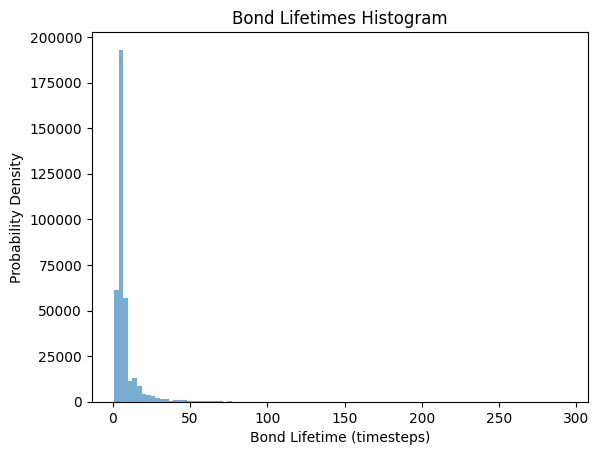

In [32]:
import numpy as np


def plot_bond_lifetimes(bond_lifetimes, title='Bond Lifetimes Histogram'):
    """
    Plot histogram of bond lifetimes.
    Parameters:
        bond_lifetimes (pd.DataFrame): DataFrame containing bond lifetimes
    """

    all_lifetimes = bond_lifetimes['lifetime']
    max_cutoff = 4000
    min_cutoff = 0
    filtered_data = all_lifetimes[(all_lifetimes < max_cutoff) & (all_lifetimes > min_cutoff)] 
    hist, _ = np.histogram(filtered_data, bins=100)

    plt.hist(filtered_data, bins=100, alpha=0.6, label='Data')
    plt.xlabel('Bond Lifetime (timesteps)')
    plt.ylabel('Probability Density')
    plt.title(title)
    print(hist)
    plt.show()


file = 'data/bond_lifetimes.csv'
bond_lifetimes = pd.read_csv(file, delimiter=',')
# graph histogram of bond lifetimes
print("Average bond lifetime:", avg := bond_lifetimes['lifetime'].mean())
plot_bond_lifetimes(bond_lifetimes, title='Bond Lifetimes Histogram')

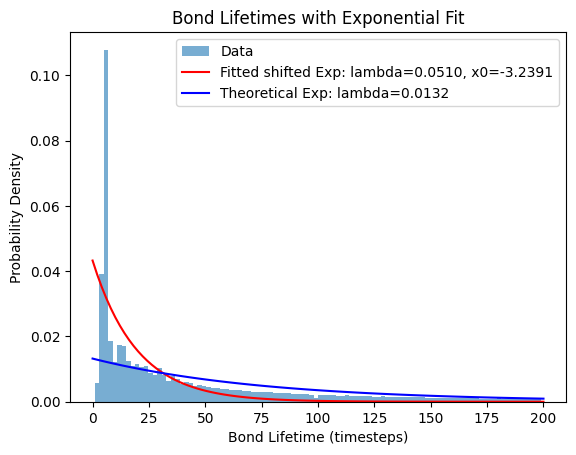

In [117]:
# curve fitting bond lifetime distribution to shifted exponential decay
import numpy as np
from scipy.optimize import curve_fit

# ignore lifetimes longer than cutoff timesteps for fitting
min_cutoff = 0
max_cutoff = 200
fit_start = 0  # Start fitting from this timestep to skip the initial rise

def exponential(x, a, x0):
    return a * np.exp(-a * (x - x0))

# Filter data for both histogram and fitting
filtered_data = bond_lifetimes['lifetime'][(bond_lifetimes['lifetime'] < max_cutoff) & (bond_lifetimes['lifetime'] > min_cutoff)]
hist, bin_edges = np.histogram(filtered_data, density=True, bins=100)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Only fit to data after fit_start
fit_mask = bin_centers >= fit_start
x_fit = bin_centers[fit_mask]
y_fit = hist[fit_mask]

popt, pcov = curve_fit(exponential, x_fit, y_fit, p0=(1, fit_start))

l = 0.5

plt.hist(filtered_data, bins=100, alpha=0.6, density=True, label='Data')
x_plot = np.linspace(fit_start, max_cutoff, 100)
plt.plot(x_plot, exponential(x_plot, *popt), 'r-', 
         label=f"Fitted shifted Exp: lambda={popt[0]:.4f}, x0={popt[1]:.4f}")
plt.plot(x_plot, exponential(x_plot, 1/avg, 0), 'b-', label=f'Theoretical Exp: lambda={1/avg:.4f}')
# plt.axvline(fit_start, color='orange', linestyle='--', alpha=0.7, label=f'Fit starts at {fit_start}')
plt.xlabel('Bond Lifetime (timesteps)')
plt.ylabel('Probability Density')
plt.title('Bond Lifetimes with Exponential Fit')
plt.legend()
plt.show()
